# LED Characterization Data Processor

Processes raw voltage data from an ESP32 + MCP4725 DAC + LMP358P VCCS LED characterization system.

**Data files (pre-trimmed to 768 points = 256 steps × 3 readings):**
| File | Description | Unit |
|------|-------------|------|
| `256_MCP_Out.txt` | DAC output baseline (multimeter) | mV |
| `White_LED_Sense.txt` | Sense resistor voltage with white LED | mV |
| `Red_LED.txt` | Red LED forward voltage | V |
| `Blue_LED.txt` | Blue LED forward voltage | V |
| `White_LED.txt` | White LED forward voltage | V |
| `Yellow_LED.txt` | Yellow LED forward voltage | V |
| `Green_LED.txt` | Green LED forward voltage | V |

**Circuit:**
```
MCP4725 DAC → 10kΩ/2kΩ voltage divider → LMP358P op-amp (+input)
Op-amp output → 2N2222 → LED (from 9V) → R_sense (10Ω) → GND
R_sense voltage → op-amp (−input, feedback loop = VCCS)
```

Ideal full-scale: 3300 × (2k / 12k) = **550 mV** across R_sense  
256 DAC steps (codes 0–255), 3 readings per step → 768 raw data points per file

## 1. Setup

In [ ]:
import csv
import statistics
import os
import matplotlib.pyplot as plt
import numpy as np

# Plot styling
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

## 1a. Import Data from Google Drive

To import data from Google Drive, you'll need to mount your Drive and then copy the necessary files to the Colab environment.

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define the path to your data folder in Google Drive
# Please replace 'Your_Folder_Name_Here' with the actual name of the Google Drive folder.
# For example, if the folder is named 'LED Characterization Data' in your My Drive,
# set DRIVE_DATA_FOLDER_NAME = 'LED Characterization Data'
DRIVE_DATA_FOLDER_NAME = 'LED data'

# Create a directory for the data in the Colab environment if it doesn't exist
!mkdir -p ./data

# Copy the files from Google Drive to the current directory
# This command uses 'cp' to copy files from the mounted Google Drive path.
# '-n' means no clobber (do not overwrite existing files).
!cp -n "/content/drive/MyDrive/{DRIVE_DATA_FOLDER_NAME}/256_MCP_Out.txt" .
!cp -n "/content/drive/MyDrive/{DRIVE_DATA_FOLDER_NAME}/White_LED_Sense.txt" .
!cp -n "/content/drive/MyDrive/{DRIVE_DATA_FOLDER_NAME}/Red_LED.txt" .
!cp -n "/content/drive/MyDrive/{DRIVE_DATA_FOLDER_NAME}/Blue_LED.txt" .
!cp -n "/content/drive/MyDrive/{DRIVE_DATA_FOLDER_NAME}/White_LED.txt" .
!cp -n "/content/drive/MyDrive/{DRIVE_DATA_FOLDER_NAME}/Yellow_LED.txt" .
!cp -n "/content/drive/MyDrive/{DRIVE_DATA_FOLDER_NAME}/Green_LED.txt" .

print('Data files copied from Google Drive.')

Mounted at /content/drive
Data files copied from Google Drive.


In [ ]:
# ── Config ──

R_SENSE      = 10.0    # Sense resistor (Ω)
IDEAL_FS_MV  = 550.0   # Ideal voltage (mV)
NUM_STEPS    = 256     # DAC steps (codes 0–255)
STEP_SIZE_MV = IDEAL_FS_MV / (NUM_STEPS - 1)  # ~2.157 mV/step
READINGS_PER_STEP = 3  # Raw readings per DAC step

# File paths — update DATA_DIR to match your file locations
DATA_DIR = '.'

DAC_BASE_FILE = os.path.join(DATA_DIR, '256_MCP_Out.txt')
SENSE_FILE    = os.path.join(DATA_DIR, 'White_LED_Sense.txt')
LED_FILES     = {
    'red':    os.path.join(DATA_DIR, 'Red_LED.txt'),
    'blue':   os.path.join(DATA_DIR, 'Blue_LED.txt'),
    'white':  os.path.join(DATA_DIR, 'White_LED.txt'),
    'yellow': os.path.join(DATA_DIR, 'Yellow_LED.txt'),
    'green':  os.path.join(DATA_DIR, 'Green_LED.txt'),
}

# LED colors for plotting
LED_COLORS = {
    'red':    '#e24b4a',
    'yellow': '#d4a017',
    'green':  '#2ca02c',
    'blue':   '#3266ad',
    'white':  '#888780',
}

print(f'Step size: {STEP_SIZE_MV:.4f} mV/step')
print(f'Max current at full scale: {IDEAL_FS_MV / R_SENSE:.1f} mA')

Step size: 2.1569 mV/step
Max current at full scale: 55.0 mA


## 2. Parsing

In [ ]:
def read_raw_file(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    data_str = ','.join(lines[1:])
    values = []
    for token in data_str.split(','):
        token = token.strip()
        if token:
            try:
                values.append(float(token))
            except ValueError:
                pass
    return values


def group_by_transition(values, jump_threshold=1.5):
    if not values:
        return []

    steps = []
    group = [values[0]]

    for i in range(1, len(values)):
        if values[i] - group[0] > jump_threshold:
            steps.append(group)
            group = [values[i]]
        else:
            group.append(values[i])

    if group:
        steps.append(group)
    return steps


def group_by_triplet(values, n=3):
    return [values[i:i+n] for i in range(0, len(values) - n + 1, n)]


def steps_to_means(steps, max_n=NUM_STEPS):
    """Compute mean of each step group, return up to max_n values."""
    return [statistics.mean(g) for g in steps[:max_n]]


print('Parsing functions defined.')

Parsing functions defined.


## 3. DAC Baseline (Multimeter Reference)



In [ ]:
# Parse and process DAC baseline
raw_dac = read_raw_file(DAC_BASE_FILE)
print(f'Raw DAC data points: {len(raw_dac)}')

# Point after reset
reset_idx = raw_dac.index(0.0)
sweep_dac = raw_dac[reset_idx:]

# Group into steps by voltage transitions
dac_groups = group_by_transition(sweep_dac, jump_threshold=1.5)
dac_means  = steps_to_means(dac_groups)

# Calculate Error
n_dac      = len(dac_means)
dac_codes  = list(range(n_dac))
dac_ideal  = [i * STEP_SIZE_MV for i in dac_codes]
dac_error  = [dac_means[i] - dac_ideal[i] for i in range(n_dac)]

print(f'Steps detected: {n_dac}')
print(f'Output range:   {dac_means[0]:.2f} – {dac_means[-1]:.2f} mV')
print(f'Ideal range:    {dac_ideal[0]:.2f} – {dac_ideal[-1]:.2f} mV')
print(f'Gain error:     {(dac_means[-1] / IDEAL_FS_MV - 1) * 100:.2f}%')
print(f'Mean error:     {statistics.mean(dac_error):.2f} mV')
print(f'Error range:    {min(dac_error):.2f} to {max(dac_error):.2f} mV')

Raw DAC data points: 768
Steps detected: 256
Output range:   0.16 – 539.60 mV
Ideal range:    0.00 – 550.00 mV
Gain error:     -1.89%
Mean error:     -4.94 mV
Error range:    -10.40 to 0.66 mV


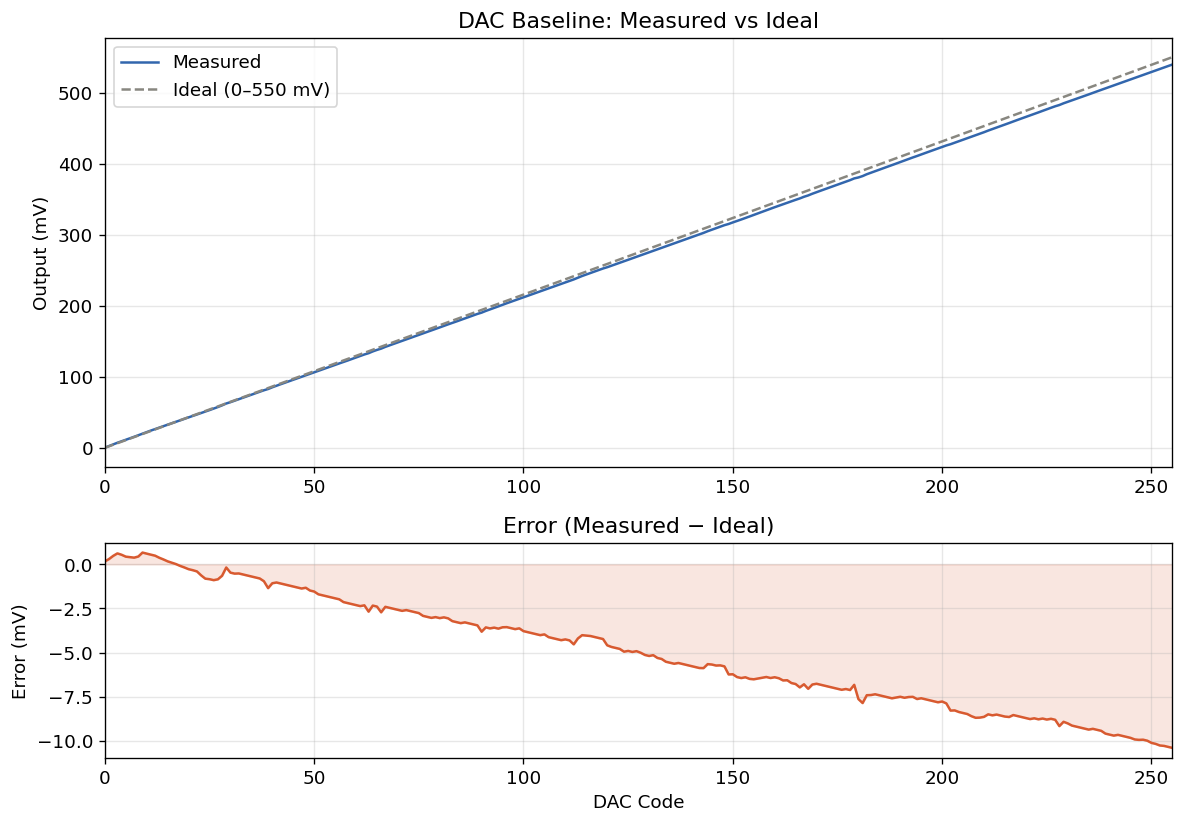

In [ ]:
# Plot DAC baseline: measured vs ideal + error
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), height_ratios=[2, 1])

ax1.plot(dac_codes, dac_means, linewidth=1.5, label='Measured', color='#3266ad')
ax1.plot(dac_codes, dac_ideal, linewidth=1.5, label='Ideal (0–550 mV)',
         color='#888780', linestyle='--')
ax1.set_ylabel('Output (mV)')
ax1.set_title('DAC Baseline: Measured vs Ideal')
ax1.legend()
ax1.set_xlim(0, 255)

ax2.plot(dac_codes, dac_error, linewidth=1.5, color='#D85A30')
ax2.fill_between(dac_codes, dac_error, alpha=0.15, color='#D85A30')
ax2.set_xlabel('DAC Code')
ax2.set_ylabel('Error (mV)')
ax2.set_title('Error (Measured − Ideal)')
ax2.set_xlim(0, 255)

plt.tight_layout()
plt.savefig('dac_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Sense Resistor Voltage (VCCS Tracking)

The sense voltage is measured across the 10Ω resistor with a white LED in circuit.  
Comparing it to the DAC baseline shows the VCCS loop tracking error — dominated by the LMP358P input offset voltage (~1 mV).

In [ ]:
# Parse and process sense resistor data
raw_sense = read_raw_file(SENSE_FILE)
print(f'Raw sense data points: {len(raw_sense)}')

reset_idx_s = raw_sense.index(0.0)
sweep_sense = raw_sense[reset_idx_s:]

sense_groups = group_by_transition(sweep_sense, jump_threshold=1.5)
sense_means  = steps_to_means(sense_groups)

# Tracking error: sense − DAC baseline
n_cmp = min(len(dac_means), len(sense_means))
tracking_err = [sense_means[i] - dac_means[i] for i in range(n_cmp)]

print(f'Steps detected:    {len(sense_means)}')
print(f'Sense range:       {sense_means[0]:.2f} – {sense_means[-1]:.2f} mV')
print(f'Tracking error:')
print(f'  Mean:   {statistics.mean(tracking_err):+.2f} mV')
print(f'  Stdev:  {statistics.stdev(tracking_err):.2f} mV')
print(f'  Range:  {min(tracking_err):+.2f} to {max(tracking_err):+.2f} mV')

Raw sense data points: 768
Steps detected:    253
Sense range:       0.08 – 531.83 mV
Tracking error:
  Mean:   -1.14 mV
  Stdev:  0.37 mV
  Range:  -1.97 to +0.48 mV


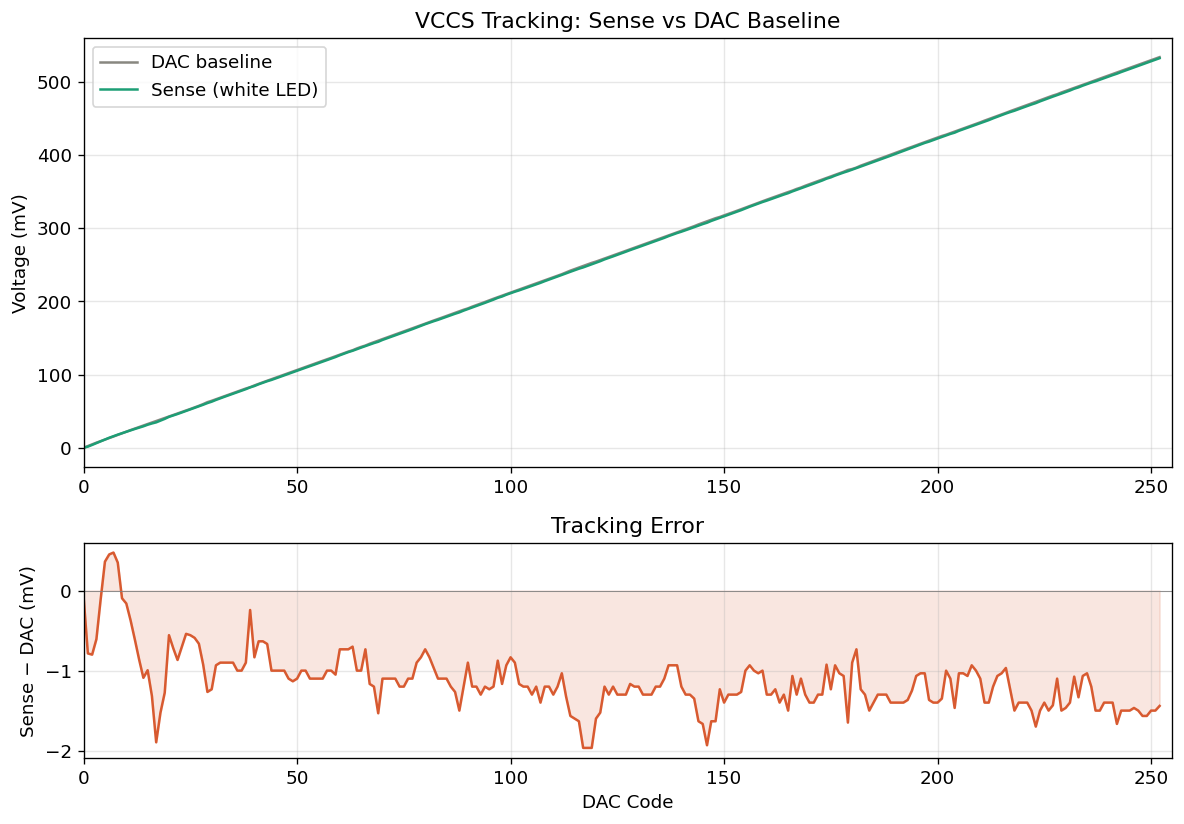

In [ ]:
# Plot sense vs DAC baseline + tracking error
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), height_ratios=[2, 1])

ax1.plot(dac_codes[:n_cmp], dac_means[:n_cmp], linewidth=1.5,
         label='DAC baseline', color='#888780')
ax1.plot(dac_codes[:n_cmp], sense_means[:n_cmp], linewidth=1.5,
         label='Sense (white LED)', color='#1D9E75')
ax1.set_ylabel('Voltage (mV)')
ax1.set_title('VCCS Tracking: Sense vs DAC Baseline')
ax1.legend()
ax1.set_xlim(0, 255)

ax2.plot(dac_codes[:n_cmp], tracking_err, linewidth=1.5, color='#D85A30')
ax2.fill_between(dac_codes[:n_cmp], tracking_err, alpha=0.15, color='#D85A30')
ax2.axhline(y=0, color='gray', linewidth=0.5)
ax2.set_xlabel('DAC Code')
ax2.set_ylabel('Sense − DAC (mV)')
ax2.set_title('Tracking Error')
ax2.set_xlim(0, 255)

plt.tight_layout()
plt.savefig('vccs_tracking.png', dpi=150, bbox_inches='tight')
plt.show()

## 4b. Multimeter vs Sense Voltage — Cross-Validation

Both the DAC baseline and the sense resistor voltage were measured with the **ZOYI ZT-300AB multimeter**.  
The DAC baseline was captured without an LED in circuit; the sense voltage was captured with the white LED in circuit.  
Since the VCCS forces V_sense ≈ V_DAC, comparing these two independent measurements cross-validates the system.

In [ ]:
# Multimeter cross-validation: sense vs DAC baseline
mm_diff = [sense_means[i] - dac_means[i] for i in range(n_cmp)]

print(f'Compared steps:  {n_cmp}')
print(f'DAC range:       {dac_means[0]:.2f} – {dac_means[n_cmp-1]:.2f} mV')
print(f'Sense range:     {sense_means[0]:.2f} – {sense_means[n_cmp-1]:.2f} mV')
print(f'Difference (Sense − DAC):')
print(f'  Mean:   {statistics.mean(mm_diff):+.2f} mV')
print(f'  Stdev:  {statistics.stdev(mm_diff):.2f} mV')
print(f'  Range:  {min(mm_diff):+.2f} to {max(mm_diff):+.2f} mV')


Compared steps:  253
DAC range:       0.16 – 533.27 mV
Sense range:     0.08 – 531.83 mV
Difference (Sense − DAC):
  Mean:   -1.14 mV
  Stdev:  0.37 mV
  Range:  -1.97 to +0.48 mV


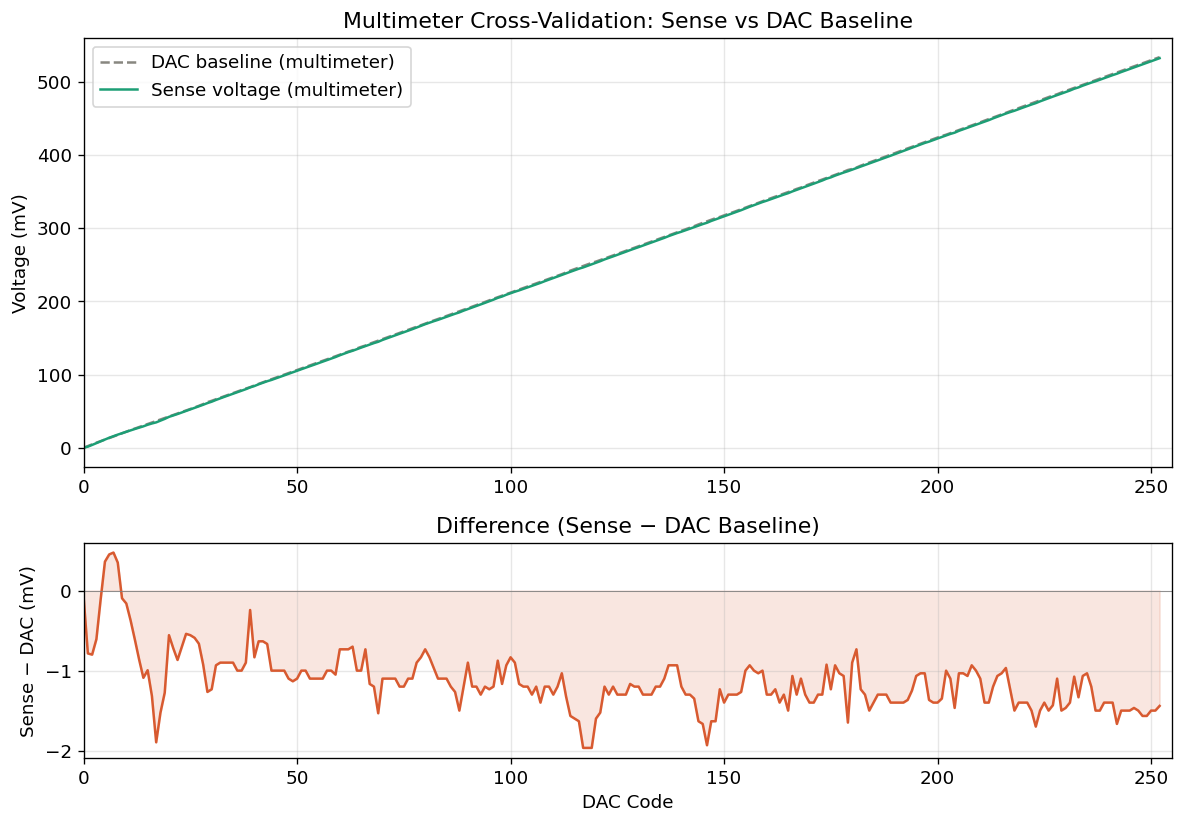

In [ ]:
# Plot multimeter sense vs DAC baseline + difference
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), height_ratios=[2, 1])

ax1.plot(dac_codes[:n_cmp], dac_means[:n_cmp], linewidth=1.5,
         label='DAC baseline (multimeter)', color='#888780', linestyle='--')
ax1.plot(dac_codes[:n_cmp], sense_means[:n_cmp], linewidth=1.5,
         label='Sense voltage (multimeter)', color='#1D9E75')
ax1.set_ylabel('Voltage (mV)')
ax1.set_title('Multimeter Cross-Validation: Sense vs DAC Baseline')
ax1.legend()
ax1.set_xlim(0, 255)

ax2.plot(dac_codes[:n_cmp], mm_diff, linewidth=1.5, color='#D85A30')
ax2.fill_between(dac_codes[:n_cmp], mm_diff, alpha=0.15, color='#D85A30')
ax2.axhline(y=0, color='gray', linewidth=0.5)
ax2.set_xlabel('DAC Code')
ax2.set_ylabel('Sense − DAC (mV)')
ax2.set_title('Difference (Sense − DAC Baseline)')
ax2.set_xlim(0, 255)

plt.tight_layout()
plt.savefig('multimeter_vs_sense.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. LED Forward Voltage (V-I Characteristics)

Each LED Vf file (pre-trimmed to 768 points) has:
- A preamble (last few readings from previous state)
- A dip below 1.0 V (DAC reset)
- The Vf sweep starting above ~1.5 V

Current is computed from the sense resistor: `I_mA = V_sense / R_sense`

In [ ]:
def process_LED_vf(filepath, name, glitch_range=(1.5, 5.0)):
    """Process one LED Vf file.

    Returns dict with 'name', 'vf_V' (list of per-step means), 'n_steps'.
    glitch_range filters out obvious data corruption.
    """
    raw = read_raw_file(filepath)
    print(f'  [{name:6s}] Raw data points: {len(raw)}')

    # Find reset dip (first value < 1.0 V)
    reset_idx = None
    for i, v in enumerate(raw):
        if v < 1.0:
            reset_idx = i
            break

    if reset_idx is None:
        print(f'  [{name}] WARNING: no reset dip found')
        return {'name': name, 'vf_V': [], 'n_steps': 0}

    # Find sweep start (first value > 1.5 V after reset)
    start_idx = None
    for i in range(reset_idx, len(raw)):
        if raw[i] >= 1.5:
            start_idx = i
            break

    if start_idx is None:
        print(f'  [{name}] WARNING: no sweep start found')
        return {'name': name, 'vf_V': [], 'n_steps': 0}

    sweep = raw[start_idx:]

    # Filter glitches
    lo, hi = glitch_range
    sweep = [v for v in sweep if lo < v < hi]

    # Group into triplets and average
    steps = group_by_triplet(sweep, n=READINGS_PER_STEP)
    means = steps_to_means(steps)

    n = len(means)
    print(f'  [{name:6s}] {n} steps, Vf: {means[0]:.3f} – {means[-1]:.3f} V')
    return {'name': name, 'vf_V': means, 'n_steps': n}


print('LED processing function defined.')

LED processing function defined.


In [ ]:
# Process all LED files
print('Processing LED forward voltage data...\n')
led_data = {}
for color, fpath in LED_FILES.items():
    if os.path.exists(fpath):
        led_data[color] = process_LED_vf(fpath, color)
    else:
        print(f'  [{color}] File not found: {fpath}')
    print()

# Compute current from sense voltage
current_mA = [v / R_SENSE for v in sense_means]
print(f'Current array: {len(current_mA)} steps, range: {current_mA[0]:.2f} – {current_mA[-1]:.2f} mA')

Processing LED forward voltage data...

  [red   ] Raw data points: 768
  [red   ] 255 steps, Vf: 1.692 – 2.168 V

  [blue  ] Raw data points: 768
  [blue  ] 255 steps, Vf: 2.509 – 3.095 V

  [white ] Raw data points: 768
  [white ] 255 steps, Vf: 2.506 – 3.338 V

  [yellow] Raw data points: 768
  [yellow] 255 steps, Vf: 1.716 – 2.041 V

  [green ] Raw data points: 768
  [green ] 255 steps, Vf: 1.725 – 2.057 V

Current array: 253 steps, range: 0.01 – 53.18 mA


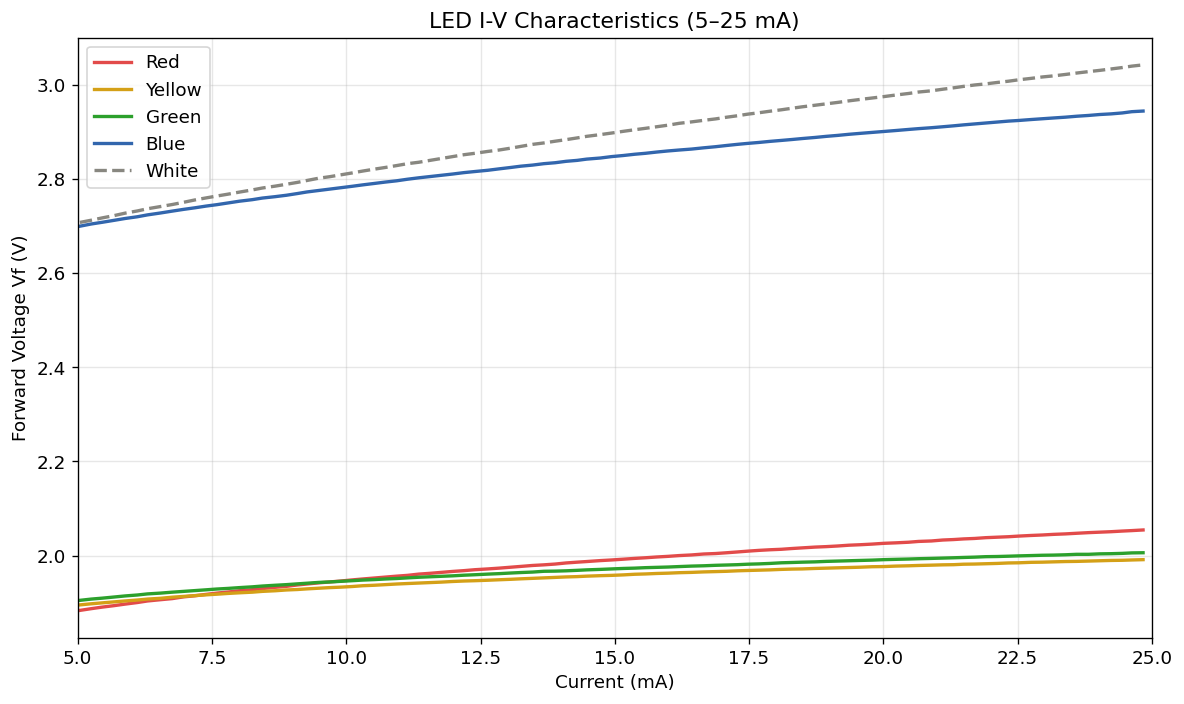

In [ ]:
# Plot LED I-V characteristics (5–25 mA range)
fig, ax = plt.subplots(figsize=(10, 6))

plot_order = ['red', 'yellow', 'green', 'blue', 'white']
linestyles = {'red': '-', 'yellow': '-', 'green': '-', 'blue': '-', 'white': '--'}

I_MIN, I_MAX = 5.0, 25.0   # mA — analysis window

for color in plot_order:
    ds = led_data.get(color)
    if ds is None or ds['n_steps'] == 0:
        continue

    n = min(len(current_mA), ds['n_steps'])
    I_arr = np.array(current_mA[:n])
    V_arr = np.array(ds['vf_V'][:n])
    mask = (I_arr >= I_MIN) & (I_arr <= I_MAX)

    ax.plot(I_arr[mask], V_arr[mask],
            linewidth=2, color=LED_COLORS[color],
            linestyle=linestyles[color], label=f"{color.capitalize()}")

ax.set_xlabel('Current (mA)')
ax.set_ylabel('Forward Voltage Vf (V)')
ax.set_title(f'LED I-V Characteristics ({I_MIN:.0f}–{I_MAX:.0f} mA)')
ax.set_xlim(I_MIN, I_MAX)
ax.legend()

plt.tight_layout()
plt.savefig('led_iv_characteristics.png', dpi=150, bbox_inches='tight')
plt.show()


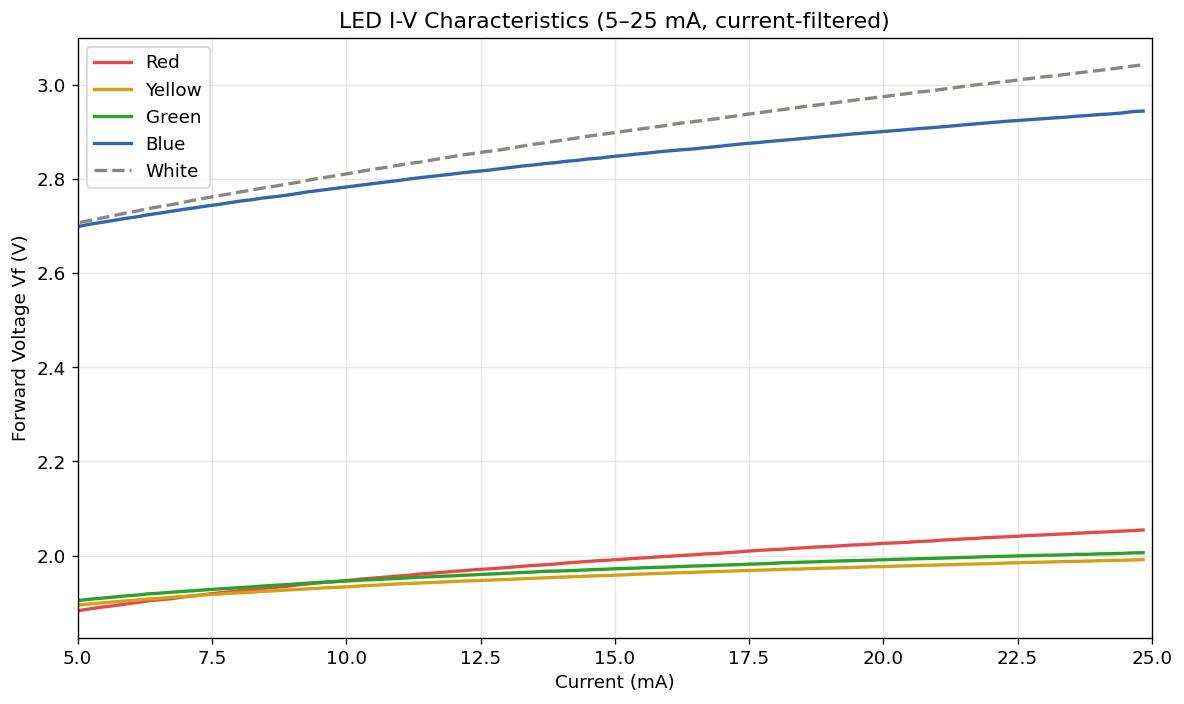

In [ ]:
# I-V plot — same 5–25 mA window, current-based filter
# (the old START_IDX transient-skip is subsumed by the 5 mA lower bound)
fig, ax = plt.subplots(figsize=(10, 6))

for color in plot_order:
    ds = led_data.get(color)
    if ds is None or ds['n_steps'] == 0:
        continue

    n = min(len(current_mA), ds['n_steps'])
    I_arr = np.array(current_mA[:n])
    V_arr = np.array(ds['vf_V'][:n])
    mask = (I_arr >= I_MIN) & (I_arr <= I_MAX)

    ax.plot(I_arr[mask], V_arr[mask],
            linewidth=2, color=LED_COLORS[color],
            linestyle=linestyles[color], label=f"{color.capitalize()}")

ax.set_xlabel('Current (mA)')
ax.set_ylabel('Forward Voltage Vf (V)')
ax.set_title(f'LED I-V Characteristics ({I_MIN:.0f}–{I_MAX:.0f} mA, current-filtered)')
ax.set_xlim(I_MIN, I_MAX)
ax.legend()

plt.tight_layout()
plt.savefig('led_iv_trimmed.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Summary: Vf at Standard Test Currents

In [ ]:
def find_nearest_idx(arr, target):
    """Index of element in arr closest to target."""
    return min(range(len(arr)), key=lambda i: abs(arr[i] - target))


test_currents = [10.0, 20.0, 50.0]

print(f'{"Color":<8}', end='')
for I in test_currents:
    print(f'  Vf@{I:.0f}mA', end='')
print(f'  Rd(20-50)  Steps')
print('─' * 62)

for color in ['red', 'yellow', 'green', 'blue', 'white']:
    ds = led_data.get(color)
    if ds is None or ds['n_steps'] == 0:
        continue

    print(f'{color:<8}', end='')
    vf_at = {}
    for I in test_currents:
        idx = find_nearest_idx(current_mA, I)
        if idx < ds['n_steps']:
            vf = ds['vf_V'][idx]
            vf_at[I] = vf
            print(f'  {vf:.3f} V', end='')
        else:
            print(f'     N/A ', end='')

    # Dynamic resistance
    if 20.0 in vf_at and 50.0 in vf_at:
        rd = (vf_at[50.0] - vf_at[20.0]) / (50.0 - 20.0) * 1000
        print(f'   {rd:5.1f} Ω', end='')
    else:
        print(f'     N/A', end='')

    print(f'    {ds["n_steps"]}')

Color     Vf@10mA  Vf@20mA  Vf@50mA  Rd(20-50)  Steps
──────────────────────────────────────────────────────────────
red       1.946 V  2.026 V  2.157 V     4.4 Ω    255
yellow    1.933 V  1.977 V  2.037 V     2.0 Ω    255
green     1.946 V  1.992 V  2.052 V     2.0 Ω    255
blue      2.781 V  2.900 V  3.080 V     6.0 Ω    255
white     2.808 V  2.974 V  3.307 V    11.1 Ω    255


## 7. Export to CSV

Three output files:
1. `dac_baseline.csv` — DAC code, ideal, measured, error, raw readings
2. `sense_vs_dac.csv` — DAC vs sense voltage comparison
3. `led_iv_characteristics.csv` — current + Vf for all LEDs

In [ ]:
# Export DAC baseline
with open('dac_baseline.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['dac_code', 'ideal_mV', 'measured_mV', 'error_mV',
                'num_readings', 'raw_readings'])
    for i in range(n_dac):
        raw_str = ';'.join(f'{v:.2f}' for v in dac_groups[i])
        w.writerow([i, f'{dac_ideal[i]:.3f}', f'{dac_means[i]:.3f}',
                    f'{dac_error[i]:.3f}', len(dac_groups[i]), raw_str])
print('Saved: dac_baseline.csv')

# Export sense vs DAC
with open('sense_vs_dac.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['dac_code', 'dac_base_mV', 'sense_mV', 'tracking_error_mV'])
    for i in range(n_cmp):
        w.writerow([i, f'{dac_means[i]:.2f}', f'{sense_means[i]:.2f}',
                    f'{tracking_err[i]:.2f}'])
print('Saved: sense_vs_dac.csv')

# Export LED I-V (all colors, limited to common length)
ordered = ['red', 'yellow', 'green', 'blue', 'white']
n_common = len(current_mA)
for c in ordered:
    ds = led_data.get(c)
    if ds and ds['n_steps'] > 0:
        n_common = min(n_common, ds['n_steps'])

with open('led_iv_characteristics.csv', 'w', newline='') as f:
    w = csv.writer(f)
    header = ['dac_code', 'current_mA']
    cols = []
    for c in ordered:
        ds = led_data.get(c)
        if ds and ds['n_steps'] >= n_common:
            header.append(f'{c}_Vf_V')
            cols.append(c)
    w.writerow(header)
    for i in range(n_common):
        row = [i, f'{current_mA[i]:.3f}']
        for c in cols:
            row.append(f'{led_data[c]["vf_V"][i]:.4f}')
        w.writerow(row)
print(f'Saved: led_iv_characteristics.csv ({n_common} rows, {cols})')

# Also export full-length version (all steps) excluding short datasets
n_full = len(current_mA)
full_cols = [c for c in ordered
             if c in led_data and led_data[c]['n_steps'] >= n_full]

if full_cols:
    with open('led_iv_full.csv', 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow(['dac_code', 'current_mA'] + [f'{c}_Vf_V' for c in full_cols])
        for i in range(n_full):
            row = [i, f'{current_mA[i]:.3f}']
            for c in full_cols:
                row.append(f'{led_data[c]["vf_V"][i]:.4f}')
            w.writerow(row)
    print(f'Saved: led_iv_full.csv ({n_full} rows, {full_cols})')

Saved: dac_baseline.csv
Saved: sense_vs_dac.csv
Saved: led_iv_characteristics.csv (253 rows, ['red', 'yellow', 'green', 'blue', 'white'])
Saved: led_iv_full.csv (253 rows, ['red', 'yellow', 'green', 'blue', 'white'])


## 8. SPICE Diode Model Extraction

Extract standard SPICE diode parameters from measured I-V data for use in LTSpice.

**SPICE diode model:** `I = Is × (exp(V / (N×Vt)) − 1)` with series resistance Rs

At currents well above Is, the measured forward voltage can be written as:

`Vf = N×Vt×ln(I/Is) + I×Rs`

Rearranging: `Vf = a×ln(I) + b×I + c`

where `a = N×Vt`, `b = Rs`, `c = −N×Vt×ln(Is)`

This is a **multilinear regression** problem — no iterative solver needed.

In [ ]:
def extract_spice_params(current_mA, vf_V, name,
                         fit_range_mA=(5.0, 25.0), Vt=25.85e-3):
    """Extract SPICE diode parameters (Is, N, Rs) from measured I-V data.

    Uses multilinear regression on the model:
      Vf = a*ln(I) + b*I + c
    where a = N*Vt, b = Rs, c = -N*Vt*ln(Is)

    Parameters
    ----------
    current_mA : list of float — measured current in mA
    vf_V       : list of float — measured forward voltage in V
    name       : str — LED color name
    fit_range_mA : tuple — (min, max) current range for fitting (default 5–25 mA)
    Vt         : float — thermal voltage (V), default 25.85 mV at 25°C

    Returns
    -------
    dict with keys: Is, N, Rs, name, fit_range, residual_mV
    """
    I_arr = np.array(current_mA) * 1e-3  # convert to A
    V_arr = np.array(vf_V)

    # Select fitting range
    lo, hi = fit_range_mA[0] * 1e-3, fit_range_mA[1] * 1e-3
    mask = (I_arr >= lo) & (I_arr <= hi)
    I_fit = I_arr[mask]
    V_fit = V_arr[mask]

    if len(I_fit) < 10:
        print(f'  [{name}] WARNING: only {len(I_fit)} points in fit range')
        return None

    # Build regression matrix: V = a*ln(I) + b*I + c
    A = np.column_stack([np.log(I_fit), I_fit, np.ones(len(I_fit))])
    result, residuals, rank, sv = np.linalg.lstsq(A, V_fit, rcond=None)
    a, b, c = result

    # Extract parameters
    N  = a / Vt
    Rs = max(b, 0.0)          # clamp to non-negative (physical constraint)
    Is = np.exp(-c / a)       # in A

    # Compute fit quality (using clamped Rs)
    V_pred = a * np.log(I_fit) + Rs * I_fit + c
    rms_err = np.sqrt(np.mean((V_fit - V_pred)**2)) * 1000  # mV

    # Model curve restricted to the fit range (no extrapolation)
    V_model_fit = a * np.log(I_fit) + Rs * I_fit + c

    return {
        'name': name,
        'Is': Is,
        'N': N,
        'Rs': Rs,
        'fit_range_mA': fit_range_mA,
        'rms_err_mV': rms_err,
        'n_fit_pts': len(I_fit),
        'I_model': I_fit * 1e3,    # mA for plotting (within fit range only)
        'V_model': V_model_fit,    # V for plotting (within fit range only)
    }


print('SPICE extraction function defined (default fit range: 5–25 mA).')


SPICE extraction function defined (default fit range: 5–25 mA).


In [ ]:
# Extract SPICE parameters for all LEDs (5–25 mA fit window)
print('Extracting SPICE diode model parameters (fit range: 5–25 mA)...\n')
print(f'{"LED":<8} {"Is (A)":>12} {"N":>6} {"Rs (ohm)":>8} {"RMS err":>10} {"Fit pts":>8}')
print('=' * 58)

FIT_RANGE_MA = (5.0, 25.0)
spice_params = {}
for color in ['red', 'yellow', 'green', 'blue', 'white']:
    ds = led_data.get(color)
    if ds is None or ds['n_steps'] == 0:
        continue

    n = min(len(current_mA), ds['n_steps'])
    params = extract_spice_params(current_mA[:n], ds['vf_V'][:n], color,
                                  fit_range_mA=FIT_RANGE_MA)

    if params:
        spice_params[color] = params
        print(f'{color:<8} {params["Is"]:>12.3e} {params["N"]:>6.2f} '
              f'{params["Rs"]:>7.2f}  {params["rms_err_mV"]:>8.2f} mV '
              f'{params["n_fit_pts"]:>6d}')


Extracting SPICE diode model parameters (fit range: 5–25 mA)...

LED            Is (A)      N Rs (ohm)    RMS err  Fit pts
red         7.274e-14   2.90    2.64      0.35 mV     95
yellow      7.430e-19   2.01    0.68      0.21 mV     95
green       5.131e-18   2.13    0.68      0.26 mV     95
blue        2.770e-16   3.38    5.53      1.05 mV     95
white       8.949e-18   3.02   10.81      1.00 mV     95


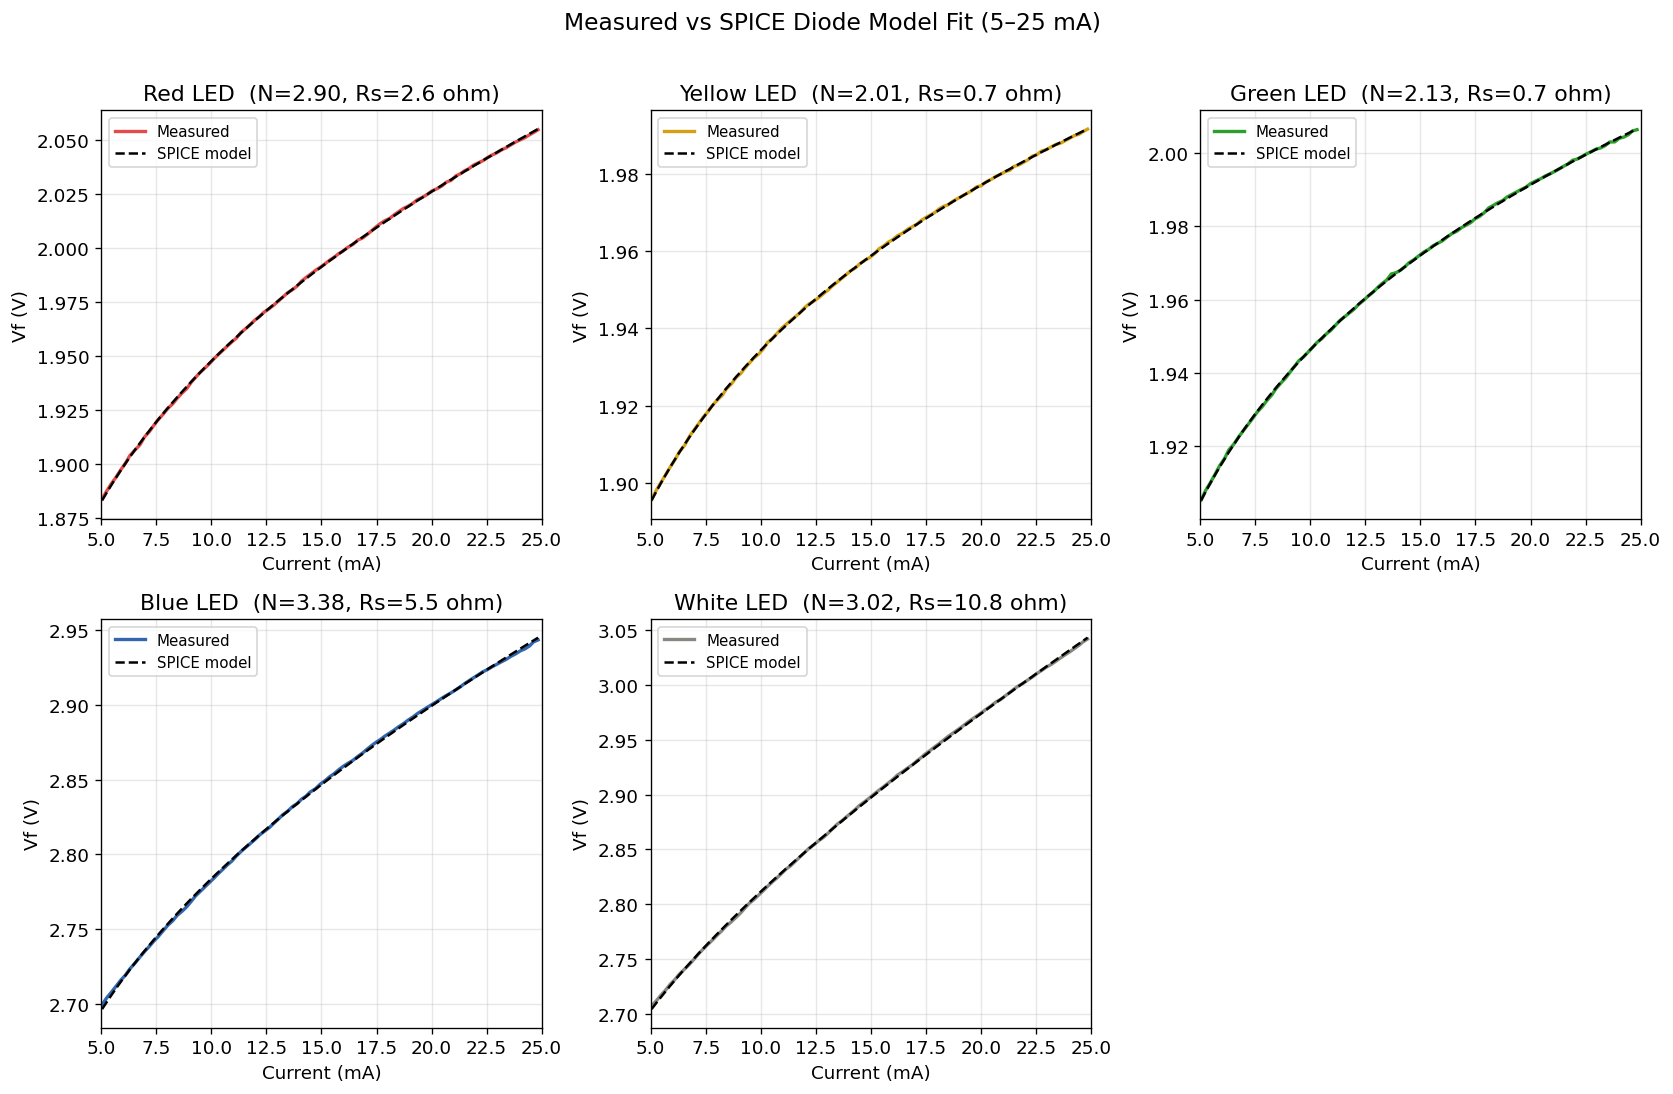

In [ ]:
# Plot measured vs SPICE model fit for all LEDs (5–25 mA)
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for idx, color in enumerate(['red', 'yellow', 'green', 'blue', 'white']):
    ax = axes[idx]
    ds = led_data.get(color)
    sp = spice_params.get(color)
    if ds is None or sp is None:
        continue

    n = min(len(current_mA), ds['n_steps'])
    I_meas = np.array(current_mA[:n])
    V_meas = np.array(ds['vf_V'][:n])
    lo, hi = sp['fit_range_mA']
    m = (I_meas >= lo) & (I_meas <= hi)

    # Measured data within fit window
    ax.plot(I_meas[m], V_meas[m],
            linewidth=2, color=LED_COLORS[color], label='Measured')

    # Model fit (already restricted to fit range)
    ax.plot(sp['I_model'], sp['V_model'],
            linewidth=1.5, color='black', linestyle='--', label='SPICE model')

    ax.set_xlabel('Current (mA)')
    ax.set_ylabel('Vf (V)')
    ax.set_title(f'{color.capitalize()} LED  (N={sp["N"]:.2f}, Rs={sp["Rs"]:.1f} ohm)')
    ax.legend(fontsize=9)
    ax.set_xlim(lo, hi)

# Hide unused subplot
axes[5].set_visible(False)

plt.suptitle('Measured vs SPICE Diode Model Fit (5–25 mA)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('spice_model_fit.png', dpi=150, bbox_inches='tight')
plt.show()


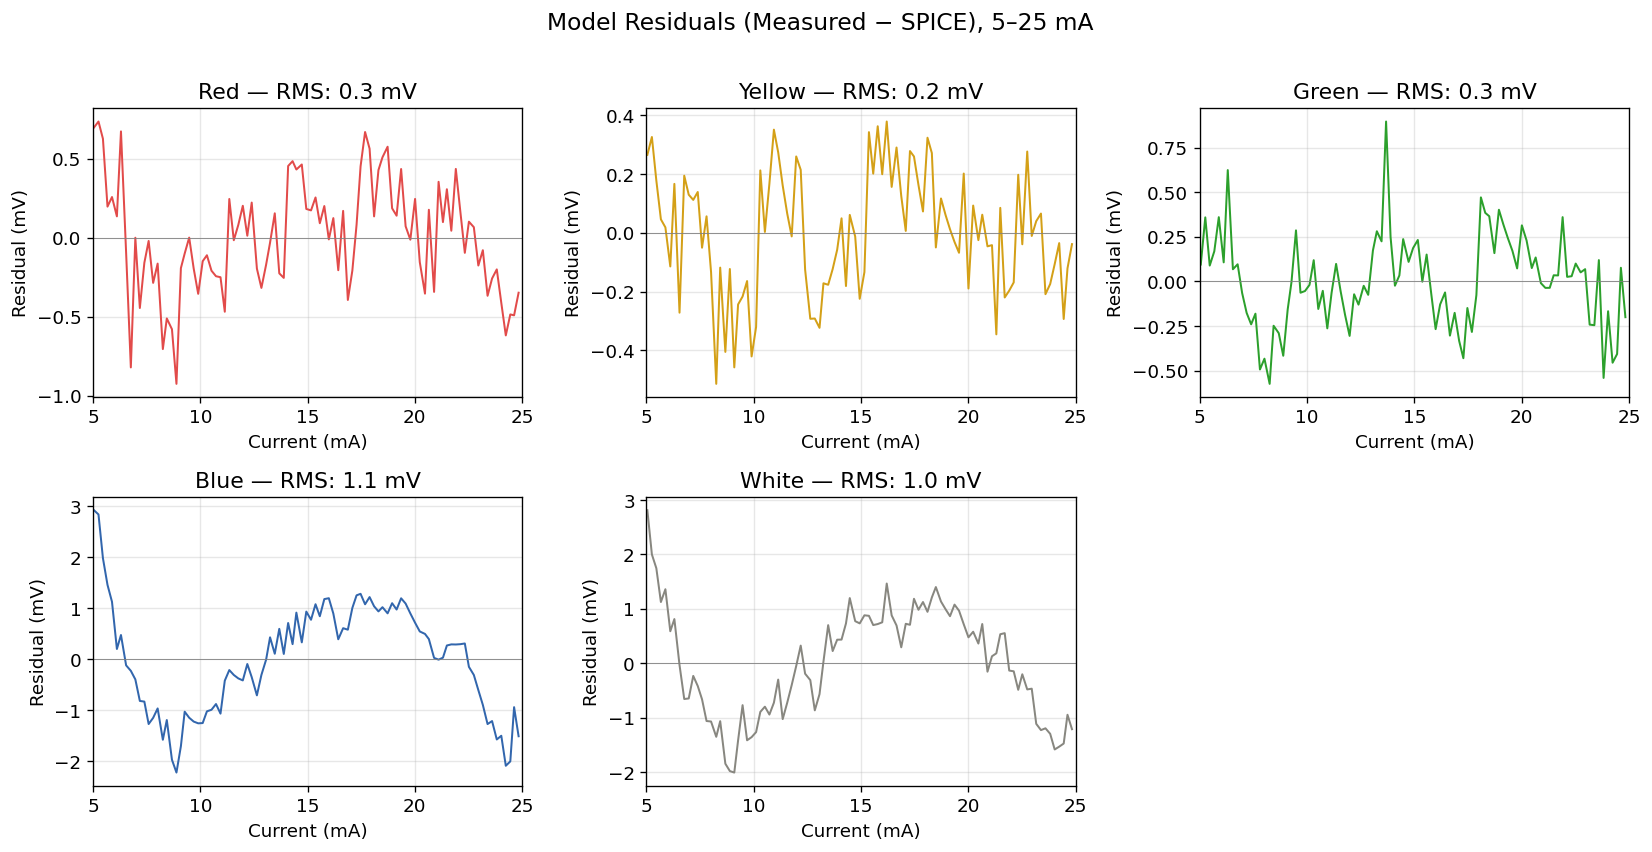

In [ ]:
# Plot residuals (model error) for each LED — within 5–25 mA fit window
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

Vt = 25.85e-3

for idx, color in enumerate(['red', 'yellow', 'green', 'blue', 'white']):
    ax = axes[idx]
    ds = led_data.get(color)
    sp = spice_params.get(color)
    if ds is None or sp is None:
        continue

    n = min(len(current_mA), ds['n_steps'])
    I_meas = np.array(current_mA[:n])
    V_meas = np.array(ds['vf_V'][:n])

    # Restrict to fit window
    lo, hi = sp['fit_range_mA']
    m = (I_meas >= lo) & (I_meas <= hi)
    I_pos = I_meas[m] * 1e-3   # to A
    V_pos = V_meas[m]

    # Model prediction at measured currents
    V_pred = sp['N'] * Vt * np.log(I_pos / sp['Is']) + I_pos * sp['Rs']
    residual = (V_pos - V_pred) * 1000  # mV

    ax.plot(I_meas[m], residual, linewidth=1.2, color=LED_COLORS[color])
    ax.axhline(y=0, color='gray', linewidth=0.5)

    ax.set_xlabel('Current (mA)')
    ax.set_ylabel('Residual (mV)')
    ax.set_title(f'{color.capitalize()} — RMS: {sp["rms_err_mV"]:.1f} mV')
    ax.set_xlim(lo, hi)

axes[5].set_visible(False)

plt.suptitle('Model Residuals (Measured − SPICE), 5–25 mA', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('spice_residuals.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. LTSpice Model Output

Generate `.model` statements and a `.lib` file ready to drop into LTSpice.

**Usage in LTSpice:**
1. Save the `.lib` file to your LTSpice library folder
2. Add `.include LED_measured.lib` to your schematic
3. Use the diode symbol and set the model name (e.g. `RED_LED`)

In [ ]:
# Generate LTSpice .model statements
print('=' * 65)
print('  LTSpice DIODE MODEL STATEMENTS')
print('  Extracted from measured I-V data')
print('=' * 65)
print()

model_lines = []
for color in ['red', 'yellow', 'green', 'blue', 'white']:
    sp = spice_params.get(color)
    if sp is None:
        continue

    model_name = f'{color.upper()}_LED'
    line = (f'.model {model_name} D('
            f'Is={sp["Is"]:.4e} '
            f'N={sp["N"]:.4f} '
            f'Rs={sp["Rs"]:.4f})')
    model_lines.append(line)
    print(line)

print()
print('-' * 65)

# Save as .lib file
lib_lines = []
lib_lines.append('* LED SPICE Models - Extracted from measured I-V data')
lib_lines.append('* System: ESP32 + MCP4725 DAC + LMP358P VCCS + 10 ohm sense')
lib_lines.append('* Fitting range: 2-45 mA, T = 25 C')
lib_lines.append('*')
lib_lines.append('* Parameters: Is = saturation current')
lib_lines.append('*             N  = ideality factor')
lib_lines.append('*             Rs = series resistance')
lib_lines.append('*')

for color in ['red', 'yellow', 'green', 'blue', 'white']:
    sp = spice_params.get(color)
    if sp is None:
        continue
    model_name = f'{color.upper()}_LED'
    lib_lines.append(f'* {color.capitalize()} LED: RMS fit error = {sp["rms_err_mV"]:.2f} mV')
    lib_lines.append(f'.model {model_name} D(Is={sp["Is"]:.4e} N={sp["N"]:.4f} Rs={sp["Rs"]:.4f})')
    lib_lines.append('')

lib_text = chr(10).join(lib_lines)
with open('LED_measured.lib', 'w') as f:
    f.write(lib_text)
print('Saved: LED_measured.lib')

# Also save parameter summary CSV
with open('spice_parameters.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['color', 'model_name', 'Is_A', 'N', 'Rs_ohm',
                'rms_err_mV', 'fit_range_lo_mA', 'fit_range_hi_mA', 'n_fit_pts'])
    for color in ['red', 'yellow', 'green', 'blue', 'white']:
        sp = spice_params.get(color)
        if sp is None:
            continue
        w.writerow([color, f'{color.upper()}_LED',
                    f'{sp["Is"]:.6e}', f'{sp["N"]:.4f}', f'{sp["Rs"]:.4f}',
                    f'{sp["rms_err_mV"]:.2f}',
                    sp['fit_range_mA'][0], sp['fit_range_mA'][1],
                    sp['n_fit_pts']])
print('Saved: spice_parameters.csv')

  LTSpice DIODE MODEL STATEMENTS
  Extracted from measured I-V data

.model RED_LED D(Is=7.2736e-14 N=2.8980 Rs=2.6392)
.model YELLOW_LED D(Is=7.4304e-19 N=2.0078 Rs=0.6838)
.model GREEN_LED D(Is=5.1314e-18 N=2.1312 Rs=0.6789)
.model BLUE_LED D(Is=2.7698e-16 N=3.3811 Rs=5.5253)
.model WHITE_LED D(Is=8.9488e-18 N=3.0183 Rs=10.8071)

-----------------------------------------------------------------
Saved: LED_measured.lib
Saved: spice_parameters.csv
